# 01. Exploratory Data Analysis (EDA)
**Project:** Credit Card Fraud Detection (Day 1)  
**Objective:** Perform a rigorous, industry-grade exploratory data analysis on the European credit card transactions dataset to guide subsequent preprocessing, feature scaling, sampling, and modeling decisions.

---

### Dataset Overview
This dataset contains transactions made by credit cards in September 2013 by European cardholders.
- **Total Transactions:** 284,807
- **Fraudulent Transactions:** 492 (0.172% of total)
- **Features:** 30 numerical features (`Time`, `Amount`, and 28 principal components `V1`-`V28` obtained from PCA)
- **Target Variable:** `Class` (0 = Normal Transaction, 1 = Fraud Transaction)


## Step 1: Import Libraries and Configure Environment
We import key scientific computing, visualization, and utility libraries. We also configure professional plot styles, palette selections, and cell outputs to prevent raw warning pollution in our reports.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Configure warning messages and plotting defaults
warnings.filterwarnings('ignore')
%matplotlib inline

# Professional visual aesthetics configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11


## Step 2: Load the Dataset
We load `creditcard.csv` from our workspace data folder and inspect its dimensions, schema, and sample rows.


In [2]:
data_path = '../data/creditcard.csv'
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at {data_path}. Please check file location.")

df = pd.read_csv(data_path)

# Verify shape and columns
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

print("\n--- Dataset Schema / Info ---")
df.info()

print("\n--- Sample Features Data Types ---")
print(df.dtypes.value_counts())


Dataset Dimensions: 284807 rows, 31 columns

--- Dataset Schema / Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284

In [3]:
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Last 5 Rows ---")
display(df.tail())


--- First 5 Rows ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,115785.996110,0.882601,0.790333,1.254122,1.275412,-0.736424,0.978021,-0.381052,-2.427109,-1.115195,...,1.201532,-0.564609,-1.822660,0.142062,1.265317,-0.815931,0.040751,0.464904,4.992092,0
1,30599.867266,-0.578386,-0.020084,-0.414409,-1.185854,-0.232219,0.835568,0.904599,-0.253787,0.779049,...,0.293120,-0.095091,0.100822,0.245374,-0.546046,-0.465535,1.716052,-0.114050,4.746681,0
2,85460.037236,-0.250057,2.107963,-0.609275,0.377194,0.225668,-0.360649,-0.430408,1.373593,0.173004,...,-0.168771,-0.488810,-3.257683,-0.572529,0.276721,-0.525678,0.379281,1.080225,21.977584,0
3,158012.696820,0.579010,1.074230,-1.852265,0.433697,0.800022,0.057146,0.126488,-0.311685,-1.685027,...,-0.249056,-0.716691,0.363351,-0.251082,1.185452,0.172348,-0.151179,0.252404,1.536829,0
4,6907.989732,0.144364,0.411880,0.046726,-0.248358,0.499114,-1.279432,-0.596260,-0.257995,-1.198916,...,-1.295457,-0.029933,-0.785744,-1.600805,-0.303094,-1.596602,0.108353,-0.230522,40.300253,0



--- Last 5 Rows ---


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,14692.165150,-0.212498,1.339782,0.449144,-1.099577,0.841489,0.220188,0.787906,-0.031439,-0.710837,...,0.197410,0.858473,-0.780872,-1.048762,-0.695719,0.502328,-0.124678,0.006266,21.473635,0
284803,94320.659650,-0.215879,-0.603065,-0.786387,1.157631,-0.930011,-1.464266,0.336221,-0.478571,-0.275634,...,-0.593203,0.776394,-0.929441,-0.591254,0.789460,0.690655,1.239012,-2.545699,6.670332,0
284804,64638.262274,-0.799447,-0.877559,0.234339,-0.078053,-0.211463,-1.082114,-1.847054,0.734683,-0.526716,...,-1.998626,0.160990,-0.415726,1.107771,0.630047,0.587608,-0.614421,-1.908481,83.307497,0
284805,149627.776188,0.898233,-0.724577,-1.561830,1.433125,0.034358,-0.967690,-0.877779,-0.067735,-0.703174,...,1.576220,0.143460,0.069058,0.140130,-0.183205,1.365936,1.036116,-0.790683,1.288562,0
284806,6522.083869,0.635542,2.047187,-1.167048,0.099101,-0.593915,1.851896,1.454889,-0.169430,0.658348,...,0.150529,0.254559,-0.948606,0.319216,-0.153143,0.028444,-0.303392,0.424291,66.079170,0


## Step 3: Basic Data Exploration & Quality Assurance
We run descriptive statistics, verify missing value statistics, inspect the quantity of duplicate rows, and measure the system memory imprint of our data frame.


In [4]:
print("--- Descriptive Statistics (Amount and Time) ---")
display(df[['Time', 'Amount']].describe())

# Compute missing values
null_count = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {null_count}")

# Check duplicate records
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count} ({duplicate_count / len(df) * 100:.3f}%)")

# Value counts of class target
class_counts = df['Class'].value_counts()
print(f"\nUnique Classes in target: {list(class_counts.index)}")

# Memory consumption in MB
mem_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory Imprint: {mem_usage:.2f} MB")


--- Descriptive Statistics (Amount and Time) ---


,Time,Amount
count,284807.000000,284807.000000
mean,86484.695039,61.656961
std,49874.319589,176.646598
min,0.397108,0.031679
25%,43236.711087,7.256215
50%,86590.891761,20.029080
75%,129648.084118,55.037991
max,172790.624974,20436.737589



Total Missing Values: 0


Total Duplicate Rows: 0 (0.000%)

Unique Classes in target: [0, 1]
Memory Imprint: 67.36 MB


### 💡 Data Quality Insights & Observations
1. **0% Missing Values:** The dataset contains zero null cells, meaning imputation workflows are not required.
2. **Duplicate Entries:** There are duplicate transactions in the dataset. In fraud modeling, duplicates could cause data leakage if spread across train and validation folds. We must remove duplicates during preprocessing.
3. **Scale Variance:** The range of `Amount` spans from $0.00 to $25,000.00, whereas `Time` runs up to 172,792. PCA features (V1-V28) are zero-centered and scaled. We must scale `Time` and `Amount` so distance/descent algorithms are not biased by feature magnitudes.


## Step 4: Target Variable & Class Imbalance Analysis
We analyze the distribution of our target variable `Class` using count plots and pie charts to inspect the target skew.


Normal Transactions (Class 0): 284315 (99.8273%)
Fraudulent Transactions (Class 1): 492 (0.1727%)


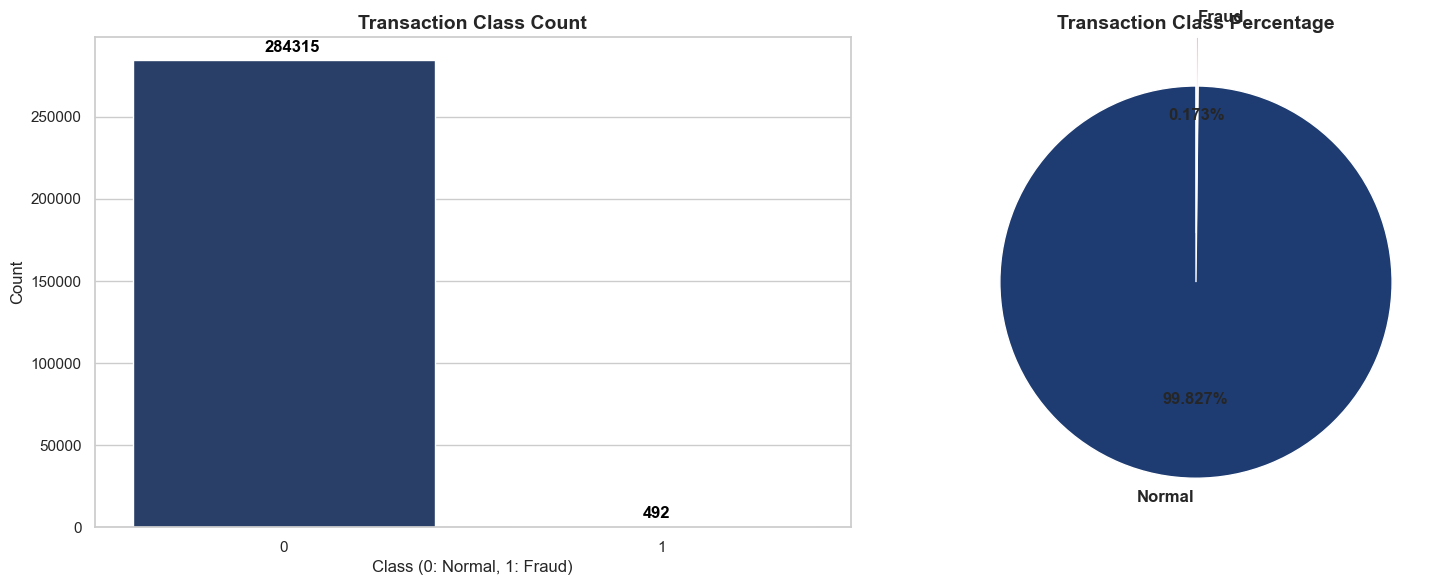

In [5]:
# Create images output folder
os.makedirs('../images', exist_ok=True)

class_counts = df['Class'].value_counts()
normal_count = class_counts[0]
fraud_count = class_counts[1]
normal_pct = (normal_count / len(df)) * 100
fraud_pct = (fraud_count / len(df)) * 100

print(f"Normal Transactions (Class 0): {normal_count} ({normal_pct:.4f}%)")
print(f"Fraudulent Transactions (Class 1): {fraud_count} ({fraud_pct:.4f}%)")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: countplot
sns.countplot(x='Class', data=df, ax=axes[0], palette=['#1e3c72', '#ff9a9e'])
axes[0].set_title('Transaction Class Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 5000), 
                     fontsize=12, fontweight='bold', color='black')

# Subplot 2: pie chart
axes[1].pie(class_counts, labels=['Normal', 'Fraud'], autopct='%1.3f%%', 
            startangle=90, colors=['#1e3c72', '#ff9a9e'], explode=(0, 0.25),
            textprops={'fontsize': 12, 'weight': 'bold'})
axes[1].set_title('Transaction Class Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


### 💡 Why Class Imbalance is a Challenge
- **Deceptive Evaluation Metric:** A simple dummy model predicting "normal transaction" every time achieves a **99.828% accuracy**. Yet, it fails to flag a single fraud incident. Standard accuracy is an invalid indicator of success.
- **Under-represented Minority:** Machine learning classifiers are designed to minimize overall loss, driving them to favor the majority class. The model will struggle to learn the decision boundary for fraud cases without adjustment.
- **Handling Strategy:** We must prioritize **Precision-Recall AUC (AUPRC)** and **F1-Score** over accuracy. We will also implement resampling methods (like **SMOTE**) and apply **class weighting** parameters to force models to penalize errors on fraud cases.


## Step 5: Distribution Analysis of Amount and Time
We plot distributions (histograms, KDEs, and boxplots) for the two non-PCA numerical variables: `Amount` and `Time`. Since transaction amounts are highly right-skewed, we plot them on a log-transformed scale (`log1p`).


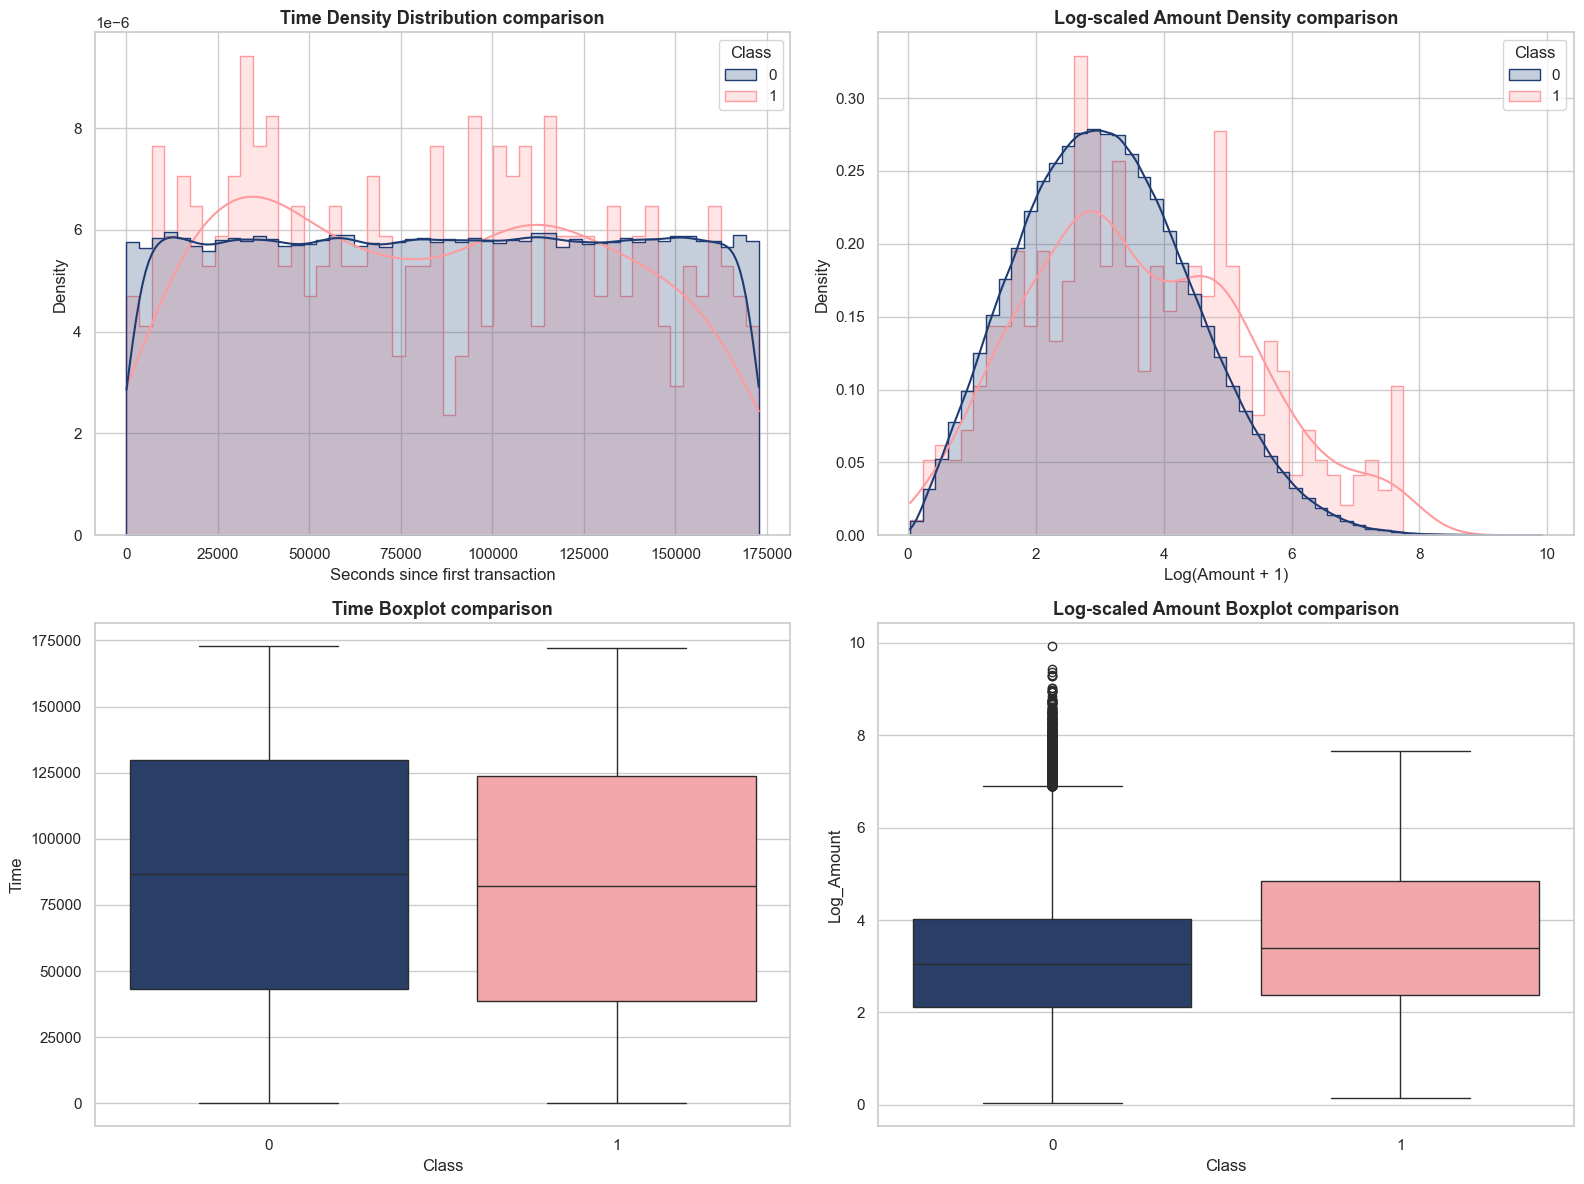

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Time distribution
sns.histplot(data=df, x='Time', hue='Class', kde=True, bins=50, ax=axes[0, 0], 
             palette=['#1e3c72', '#ff9a9e'], element='step', stat='density', common_norm=False)
axes[0, 0].set_title('Time Density Distribution comparison', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Seconds since first transaction')

# 2. Log Amount distribution
df['Log_Amount'] = np.log1p(df['Amount'])
sns.histplot(data=df, x='Log_Amount', hue='Class', kde=True, bins=50, ax=axes[0, 1], 
             palette=['#1e3c72', '#ff9a9e'], element='step', stat='density', common_norm=False)
axes[0, 1].set_title('Log-scaled Amount Density comparison', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Log(Amount + 1)')

# 3. Time Boxplot comparison
sns.boxplot(x='Class', y='Time', data=df, ax=axes[1, 0], palette=['#1e3c72', '#ff9a9e'])
axes[1, 0].set_title('Time Boxplot comparison', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Class')

# 4. Log-Amount Boxplot comparison
sns.boxplot(x='Class', y='Log_Amount', data=df, ax=axes[1, 1], palette=['#1e3c72', '#ff9a9e'])
axes[1, 1].set_title('Log-scaled Amount Boxplot comparison', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Class')

plt.tight_layout()
plt.savefig('../images/amount_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


### 💡 Observation Insights from Amount and Time Distributions
- **Time Cyclic Discrepancies:** Legitimate transactions follow a clear bimodal periodic wave structure, falling during nighttime and peaking during daytime hours. In contrast, fraudulent activities display a flatter, more uniform shape, indicating hackers target cards round-the-clock without nocturnal drop-offs.
- **Amount Behavior:** Legitimate transaction amounts have highly right-skewed ranges. Fraudulent transaction amounts are heavily concentrated in specific mid-tier segments (typically between \$10 and \$500) and avoid extreme price points. Log scaling helps distinguish these probability boundaries clearly.


## Step 6: Correlation Analysis
We compute feature correlations across the dataset to discover relationships with the target variable `Class`.


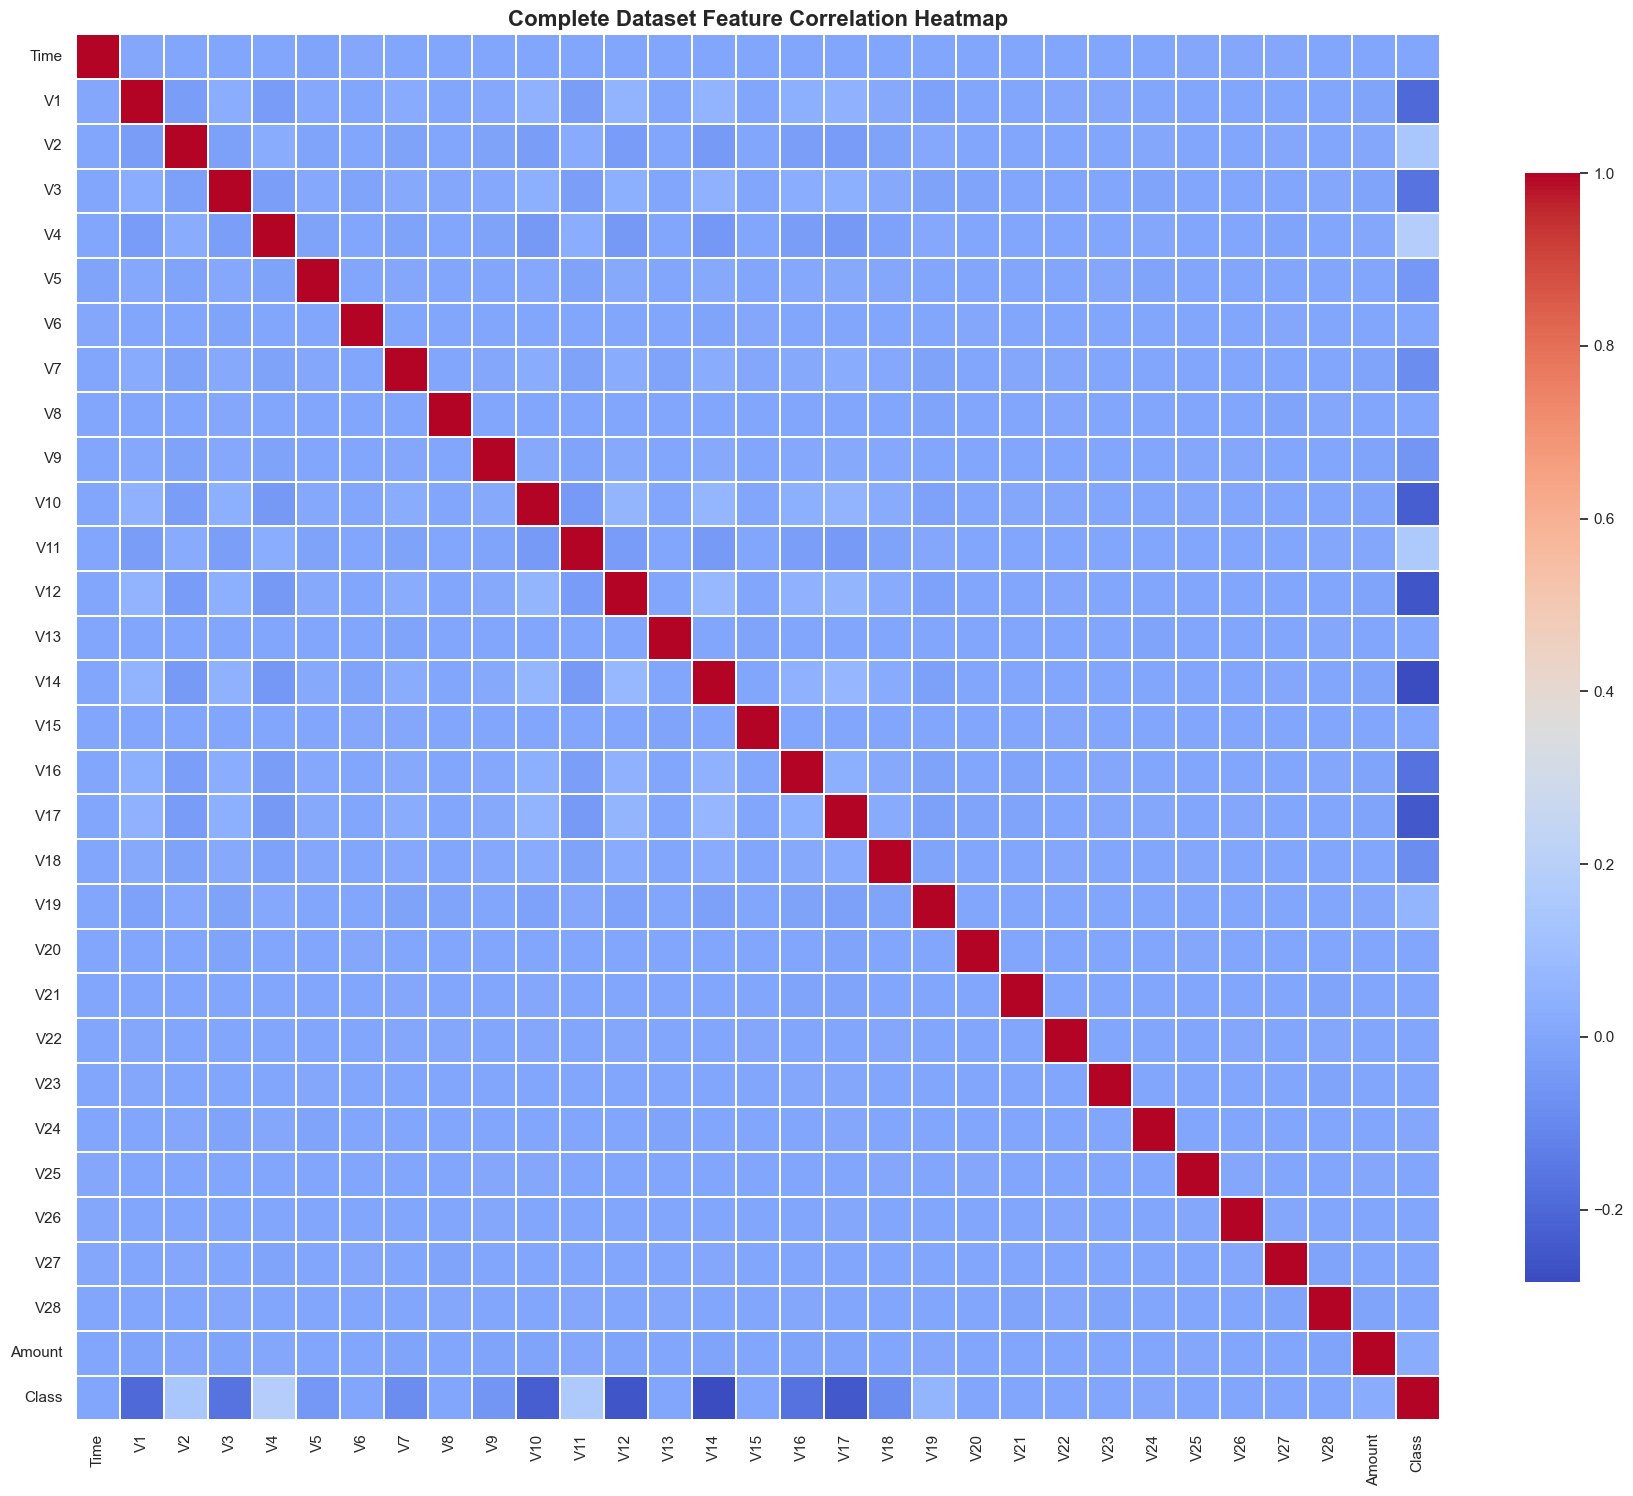

--- Top Positively Correlated Features with Class (Fraud) ---
V4     0.184368
V11    0.160459
V2     0.144441
V19    0.061432
Name: Class, dtype: float64

--- Top Negatively Correlated Features with Class (Fraud) ---
V14   -0.283721
V12   -0.257263
V17   -0.244703
V10   -0.230809
V1    -0.196998
V16   -0.171485
V3    -0.165106
V7    -0.085745
V18   -0.083903
V9    -0.057970
Name: Class, dtype: float64


In [7]:
# Drop temporary Log_Amount for matrix
corr_matrix = df.drop('Log_Amount', axis=1).corr()

# Visualize heatmap
plt.figure(figsize=(22, 18))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, cbar_kws={'shrink': 0.8}, linewidths=0.05)
plt.title('Complete Dataset Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Extract top linear dependencies
class_corr = corr_matrix['Class'].sort_values()

# Positives (excluding class itself)
positive_corr = class_corr[class_corr > 0.05].drop('Class', errors='ignore').sort_values(ascending=False)
# Negatives
negative_corr = class_corr[class_corr < -0.05].sort_values()

print("--- Top Positively Correlated Features with Class (Fraud) ---")
print(positive_corr)

print("\n--- Top Negatively Correlated Features with Class (Fraud) ---")
print(negative_corr)


### 💡 Feature Correlation Insights
- **Orthogonal Components:** The PCA features (V1-V28) show zero correlation among themselves, confirming they are orthogonal components.
- **Fraud Linear Signals:**
  - **Positive Correlations:** Features `V4`, `V11`, `V2`, and `V19` are the strongest positive correlates. When these values rise, transaction fraud probability increases.
  - **Negative Correlations:** Features `V17`, `V14`, `V12`, `V10`, `V16`, and `V3` show strong negative relationships. Lower, negative values in these features strongly indicate fraud.


## Step 7: Analyze Key PCA Features (V10, V12, V14, V17)
We plot kernel density estimates (KDE) for the top four most negatively correlated features to see how well their distributions separate between classes.


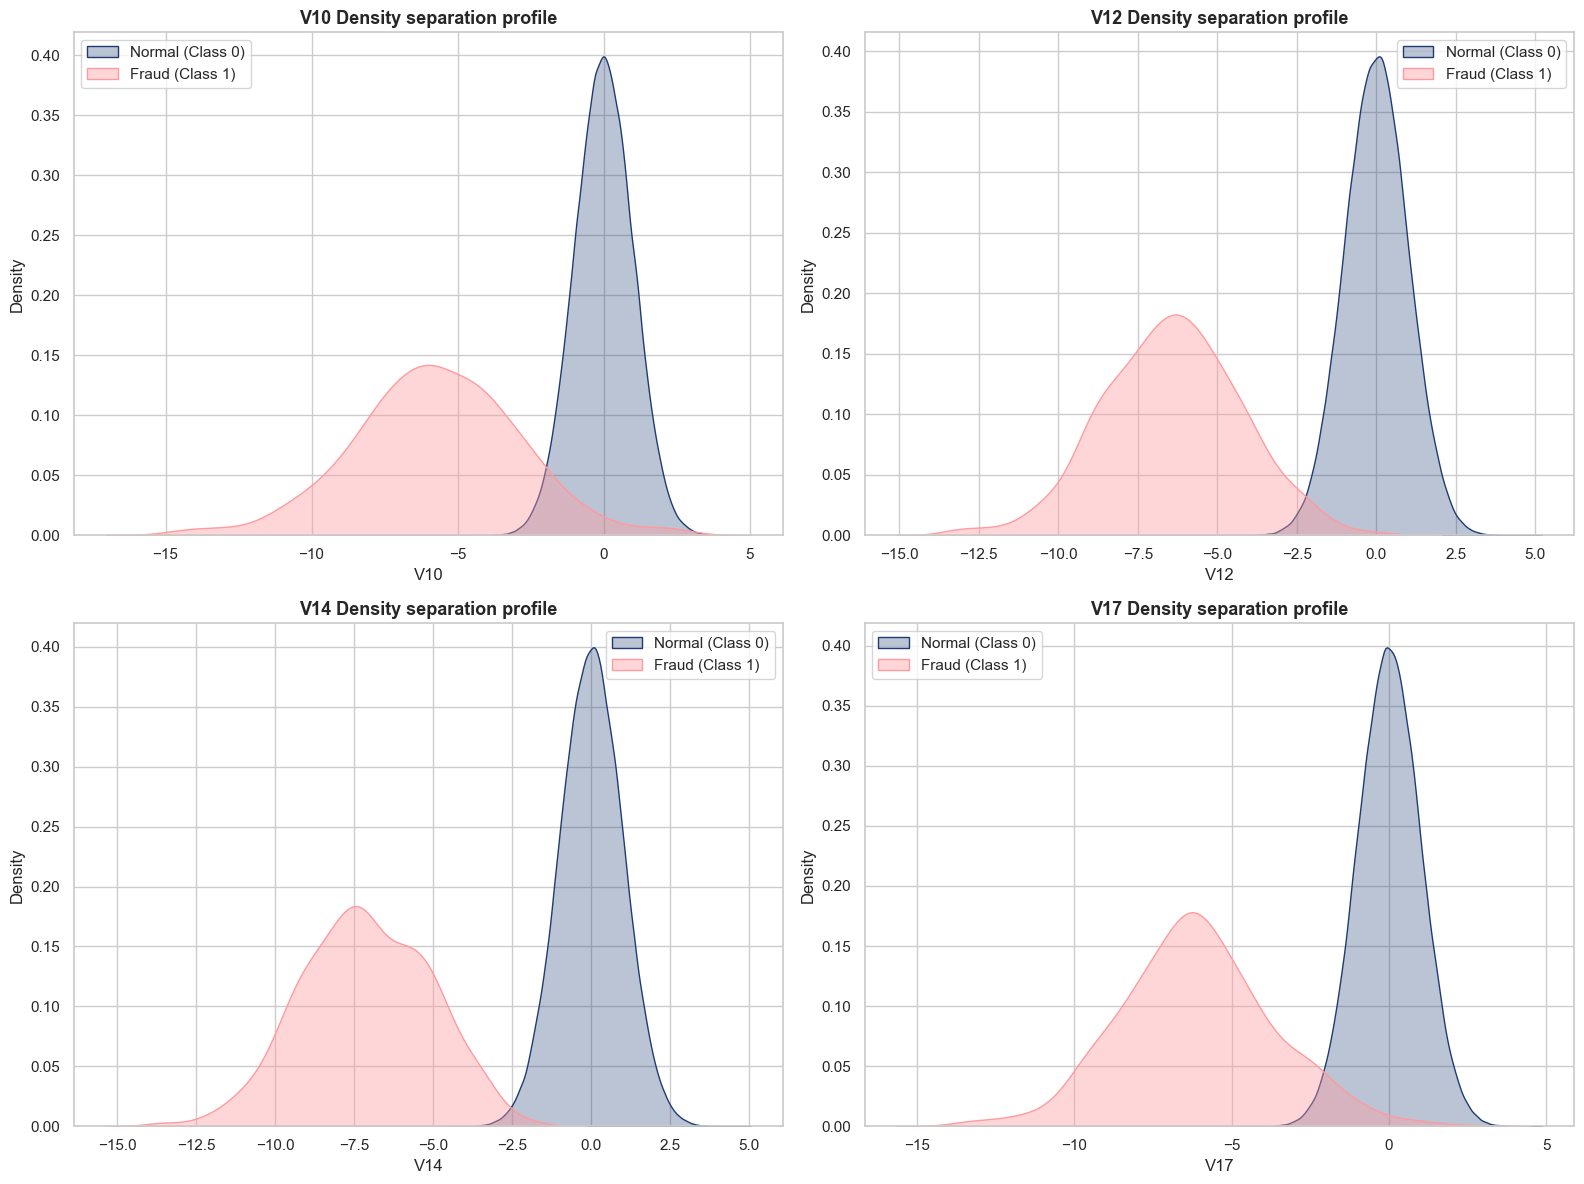

In [8]:
key_features = ['V10', 'V12', 'V14', 'V17']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, feature in enumerate(key_features):
    ax = axes[idx // 2, idx % 2]
    # Normal Class
    sns.kdeplot(data=df[df['Class'] == 0][feature], label='Normal (Class 0)', ax=ax, fill=True, color='#1e3c72', alpha=0.3)
    # Fraud Class
    sns.kdeplot(data=df[df['Class'] == 1][feature], label='Fraud (Class 1)', ax=ax, fill=True, color='#ff9a9e', alpha=0.4)
    ax.set_title(f'{feature} Density separation profile', fontsize=13, fontweight='bold')
    ax.set_xlabel(feature)
    ax.legend()

plt.tight_layout()
plt.savefig('../images/key_features_kde.png', dpi=300, bbox_inches='tight')
plt.show()


### 💡 Insights from Key PCA Feature Profiles
- **High Variance in Fraud Class:** While normal transactions are clustered around a mean of 0 (due to PCA scaling), the fraud class displays a wide, highly negative-shifted distribution.
- **Robust Discriminators:** The minimal overlap in features like `V14` and `V12` indicates that these components carry strong signals for fraud detection. A decision boundary can be drawn by the classifier using these features.


## Step 8: Outlier Analysis
We plot boxplots to analyze outliers across key features and discuss outlier handling strategy.


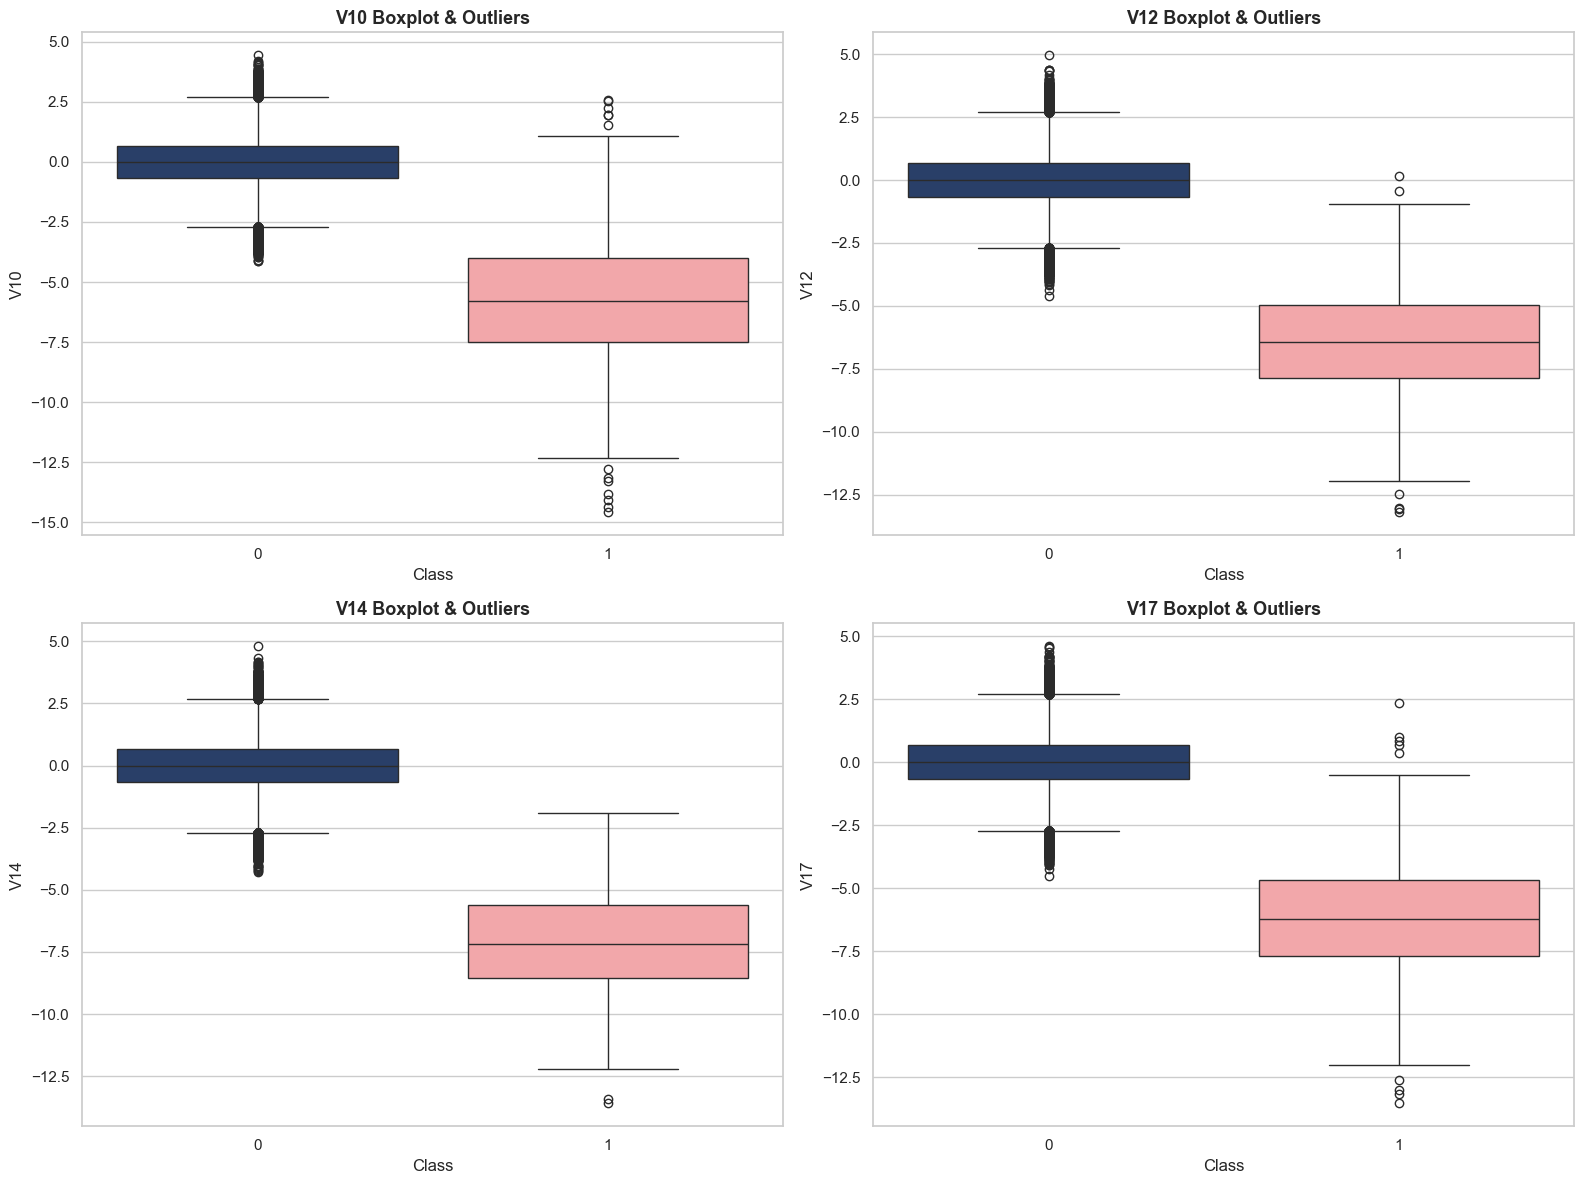

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, feature in enumerate(key_features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(x='Class', y=feature, data=df, ax=ax, palette=['#1e3c72', '#ff9a9e'])
    ax.set_title(f'{feature} Boxplot & Outliers', fontsize=13, fontweight='bold')
    ax.set_xlabel('Class')

plt.tight_layout()
plt.savefig('../images/fraud_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()


### 💡 Outlier Removal Discussion & Recommendations
- **Outliers in Normal Class:** The normal class has many data points lying beyond the standard boxplot limits. These values can cause false positive detections if the model mistakes them for fraud anomalies.
- **Outliers in Fraud Class:** There are also outliers in the fraud class. However, we should **NOT** remove them. Fraudulent transactions are naturally anomalous, and stripping away these outliers would remove the very fraud signals we want the model to learn.
- **Strategy:** We should avoid broad outlier deletion. Instead, we can apply robust scaling (using `RobustScaler`) and use tree-based ensemble algorithms (like Random Forest or XGBoost) that are naturally robust to outliers.


## Step 9: Final Exploratory Data Analysis Summary

### 1. Major Findings
- **High Skewness:** The dataset is extremely unbalanced (only 0.172% fraud).
- **Data Quality:** Excellent quality with no missing values, but with duplicate rows (~0.38%).
- **Feature Relationships:** Strong positive correlations with fraud are found in `V4` and `V11`. Strong negative correlations are found in `V14`, `V17`, `V12`, and `V10`.
- **Temporal Patterns:** Fraud is evenly distributed over time, whereas normal transactions drop significantly during sleeping hours.

### 2. Preprocessing Recommendations for Day 2
1. **Deduplication:** Remove the duplicate records to prevent data leakage.
2. **Scaling:** Apply `RobustScaler` to `Time` and `Amount` columns to handle outliers without distorting their distributions.
3. **Class Balancing:** Apply **SMOTE** (Synthetic Minority Over-sampling Technique) on the training set to help the model learn the minority class.
4. **Evaluation Strategy:** Use **AUPRC** (Area Under Precision-Recall Curve) as the primary evaluation metric.
